In [1]:
import urllib.request 
import zipfile 
import os
from pathlib import Path 

import pandas as pd 
import numpy as np 
import polars as pl

import torch 
import tiktoken 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader 

import time 
import matplotlib.pyplot as plt

In [2]:
from GPT_from_scratch import GPTModel, generate_text_simple
from GPT_from_scratch import assign, load_weights_into_gpt
from GPT_from_scratch import text_to_token_ids, token_ids_to_text
from gpt_download import download_and_load_gpt2

In [3]:
url = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip' 
zip_path = 'sms_spam_collection.zip'
extracted_path = 'sms_spam_collection' 
data_file_path = Path(extracted_path) / 'SMSSpamCollection.tsv' 

def download_and_unzip_spam_data(
    url, zip_path, extracted_path, data_file_path):
    if  data_file_path.exists():
        print(f'{data_file_path} already exists. skipping download '
              'and extraction.'
              )
        return 
    
    with urllib.request.urlopen(url) as response:
        with open(zip_path, 'wb') as out_file:
            out_file.write(response.read())
            
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
        
    orignal_file_path = Path(extracted_path) / 'SMSSpamCollection' 
    os.rename(original_file_path, data_file_path)
    print(f'File downloaded and saved as {data_file_path}')
    
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. skipping download and extraction.


In [4]:
df = pd.read_csv(
    data_file_path,
    sep = '\t',
    header = None,
    names = ['label', 'text']   
)
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
# df = pl.read_csv(
#     data_file_path, 
#     separator = '\t',
#     has_header = False,
#     new_columns = ['label', 'text'],
#     quote_char = None,
# )
# df

In [6]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
def create_balanced_dataset(df):
    num_spam = df[df['label'] == 'spam'].shape[0]
    ham_subset = df[df['label'] == 'ham'].sample(
        num_spam, random_state = 123
    )
    balanced_df = pd.concat([
          ham_subset, df[df['label'] == 'spam']
    ])
    return balanced_df 

balanced_df = create_balanced_dataset(df)
print(balanced_df['label'].value_counts())

label
ham     747
spam    747
Name: count, dtype: int64


In [8]:
balanced_df['label'] = balanced_df['label'].map({'ham': 0, 'spam': 1})

In [9]:
def random_split(df, train_frac, validation_frac):
    
    df = df.sample(
        frac = 1, random_state = 123
    ).reset_index(drop = True)
    
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)
    
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    
    return train_df, validation_df, test_df 

train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1
)

In [10]:
train_df.to_csv('train.csv', index = None)
validation_df.to_csv('validation.csv', index = None)
test_df.to_csv('test.csv', index = None)

In [11]:
import tiktoken 
tokenizer = tiktoken.get_encoding('gpt2')
print(tokenizer.encode('<|endoftext|>', allowed_special = {'<|endoftext|>'}))

[50256]


In [12]:
import torch 
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length = None, pad_token_id = 50256):
        self.data = pd.read_csv(csv_file)
        
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data['text']
        ]
        
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length 
            self.encoded_texts = [
                encoded_text[:self.max_length] for encoded_text in self.encoded_texts
            ]
            
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts
        ]
        
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]['label']
        return (
            torch.tensor(encoded, dtype = torch.long),
            torch.tensor(label, dtype = torch.long)
        )
        
    def __len__(self):
        return len(self.data)
    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [13]:
train_dataset = SpamDataset(
    csv_file = 'train.csv',
    max_length = None,
    tokenizer = tokenizer
)

In [14]:
print(train_dataset.max_length)

120


In [15]:
val_dataset = SpamDataset(
    csv_file = 'validation.csv',
    max_length = train_dataset.max_length,
    tokenizer = tokenizer 
)

test_dataset = SpamDataset(
    csv_file = 'test.csv',
    max_length = train_dataset.max_length,
    tokenizer = tokenizer
)

In [16]:
from torch.utils.data import DataLoader 

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = num_workers,
    drop_last = True 
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

In [17]:
for input_batch, target_batch in train_loader:
    pass 
print('input batch dimensions:', input_batch.shape)
print('label batch dimension:', target_batch.shape)


input batch dimensions: torch.Size([8, 120])
label batch dimension: torch.Size([8])


In [18]:
print(f'{len(train_loader)} training batches')
print(f'{len(val_loader)} validation batches')
print(f'{len(test_loader)} test batches')

130 training batches
19 validation batches
38 test batches


In [19]:
CHOOSE_MODEL = 'gpt2-small (124M)'
INPUT_PROMPT = 'Every effort moves'

BASE_CONFIG = {
    'vocab_size': 50257,
    'context_length': 1024,
    'drop_rate': 0.0,
    'qkv_bias': True 
}

model_configs = {
    'gpt2-small (124M)': {'emb_dim': 768, 'n_layers': 12, 'n_heads': 12},
    'gpt2-medium (355M)': {'emb_dim': 1024, 'n_layers': 24, 'n_heads':16},
    'gpt2-large (774M)': {'emb_dim': 1280, 'n_layers': 36, 'n_heads':20},
    'gpt2-xl (1558M)': {'emb_dim': 1600, 'n_layers': 48, 'n_heads': 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [20]:
from gpt_download import download_and_load_gpt2 
# from pretraining.py import GPTModel, load_weights_into_gpt 

model_size = CHOOSE_MODEL.split(' ')[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size = model_size, 
    models_dir = 'gpt2' 
)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [21]:
text_1 = 'Every effort moves you' 
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_1, tokenizer),
    max_new_tokens = 15,
    context_size = BASE_CONFIG['context_length']
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [22]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially" 
    " selected to receive $1000 cash or a $2000 award.'" 
)

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_2, tokenizer),
    max_new_tokens = 23,
    context_size = BASE_CONFIG['context_length']
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [23]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [24]:
for param in model.parameters():
    param.requries_grad = False

In [25]:
torch.manual_seed(123)
num_classes = 2 
model.out_head = torch.nn.Linear(
    in_features = BASE_CONFIG['emb_dim'],
    out_features = num_classes
)

In [26]:
model.out_head

Linear(in_features=768, out_features=2, bias=True)

In [27]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

In [28]:
for name, p in model.trf_blocks[-1].named_parameters():
    print(f"{name:22} {tuple(p.shape)}  {p.numel():,}")

att.W_query.weight     (768, 768)  589,824
att.W_query.bias       (768,)  768
att.W_key.weight       (768, 768)  589,824
att.W_key.bias         (768,)  768
att.W_value.weight     (768, 768)  589,824
att.W_value.bias       (768,)  768
att.out_proj.weight    (768, 768)  589,824
att.out_proj.bias      (768,)  768
ff.layers.0.weight     (3072, 768)  2,359,296
ff.layers.0.bias       (3072,)  3,072
ff.layers.2.weight     (768, 3072)  2,359,296
ff.layers.2.bias       (768,)  768
norm1.scale            (768,)  768
norm1.shift            (768,)  768
norm2.scale            (768,)  768
norm2.shift            (768,)  768


In [29]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print('inputs:', inputs)
print('inputs dimensions:', inputs.shape)

inputs: tensor([[5211,  345,  423,  640]])
inputs dimensions: torch.Size([1, 4])


In [30]:
with torch.no_grad():
    outputs = model(inputs)
print('outputs:\n', outputs)
print('outputs dimensions:', outputs.shape)

outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
outputs dimensions: torch.Size([1, 4, 2])


In [31]:
print('last output token:', outputs[:, -1, :])

last output token: tensor([[-3.5983,  3.9902]])


In [32]:
probas = torch.softmax(outputs[:, -1, :], dim = -1)
label = torch.argmax(probas)
print('class label:', label.item())

class label: 1


In [33]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print('class label:', label.item())

class label: 1


In [34]:
def calc_accuracy_loader(data_loader, model, device, num_batches = None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            
            with torch.no_grad():
                logits = model(input_batch) [:, -1, :]
            predicted_labels = torch.argmax(logits, dim = -1)
            
            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )
        else:
            break 
    return correct_predictions / num_examples

In [35]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [36]:
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches = 10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches = 10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches = 10
)

In [37]:
print(f'training accuracy: {train_accuracy * 100:.2f}%')
print(f'validation accuracy: {val_accuracy * 100:.2f}%')
print(f"Test accuracy: {test_accuracy*100:.2f}%")

training accuracy: 46.25%
validation accuracy: 45.00%
Test accuracy: 48.75%


In [38]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [39]:
def calc_loss_loader(data_loader, model, device, num_batches = None):
    total_loss = 0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device 
            )
            total_loss += loss.item()
        else:
            break 
    return total_loss / num_batches

In [40]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches = 5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches = 5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches = 5)

print(f'training loss: {train_loss:.3f}')
print(f'validation loss {val_loss:.3f}')
print(f'test loss: {test_loss:.3f}')

training loss: 2.453
validation loss 2.583
test loss: 2.322


In [41]:
def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):
    
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device 
            )
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1 
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f'Ep {epoch + 1} (step {global_step:06d}):'
                      f'Train loss {train_loss:.3f},'
                      f'Val loss {val_loss:.3f}')
        
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches = eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches = eval_iter
        )

        print(f'training accuracy: {train_accuracy * 100:2f}% | ', end = '')
        print(f'validation accuracy: {val_accuracy * 100:2f}%')
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy) 
    
    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [42]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches = eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches = eval_iter)
    model.train()
    return train_loss, val_loss

In [43]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)

for param in model.parameters():
    param.requires_grad = False

torch.manual_seed(123)
model.out_head = torch.nn.Linear(in_features=768, out_features=2)

for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

In [44]:
import time 

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr = 5e-5, weight_decay = 0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs = num_epochs, eval_freq = 50, eval_iter = 5
    )
    
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f'training completed in {execution_time_minutes:.2f} minutes')

Ep 1 (step 000000):Train loss 2.153,Val loss 2.392
Ep 1 (step 000050):Train loss 0.617,Val loss 0.637
Ep 1 (step 000100):Train loss 0.523,Val loss 0.557
training accuracy: 70.000000% | validation accuracy: 72.500000%
Ep 2 (step 000150):Train loss 0.561,Val loss 0.489
Ep 2 (step 000200):Train loss 0.419,Val loss 0.397
Ep 2 (step 000250):Train loss 0.409,Val loss 0.353
training accuracy: 82.500000% | validation accuracy: 85.000000%
Ep 3 (step 000300):Train loss 0.333,Val loss 0.320
Ep 3 (step 000350):Train loss 0.340,Val loss 0.306
training accuracy: 90.000000% | validation accuracy: 90.000000%
Ep 4 (step 000400):Train loss 0.136,Val loss 0.200
Ep 4 (step 000450):Train loss 0.153,Val loss 0.132
Ep 4 (step 000500):Train loss 0.222,Val loss 0.137
training accuracy: 100.000000% | validation accuracy: 97.500000%
Ep 5 (step 000550):Train loss 0.207,Val loss 0.143
Ep 5 (step 000600):Train loss 0.083,Val loss 0.074
training accuracy: 100.000000% | validation accuracy: 97.500000%
training comple

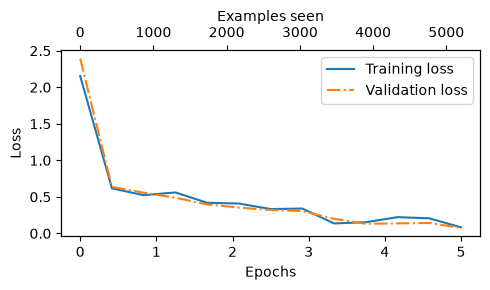

In [45]:
import matplotlib.pyplot as plt
def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    
    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

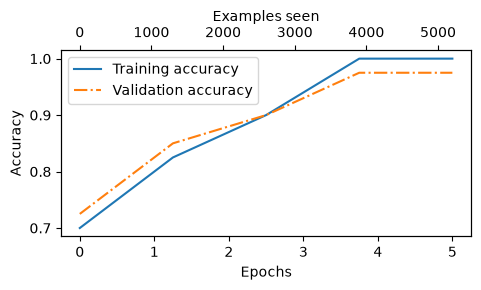

In [46]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [51]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f'training accuracy: {train_accuracy * 100:.2f}%')
print(f'validation accuracy: {val_accuracy * 100:.2f}%')
print(f'test accuracy: {test_accuracy * 100:.2f}%')

training accuracy: 97.21%
validation accuracy: 97.32%
test accuracy: 95.67%


In [52]:
def classify_review(
    text, model, tokenizer, device, max_length = None, pad_token_id = 50256):
    
    model.eval()
    
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[1]
    
    input_ids = input_ids[:min(
        max_length, supported_context_length
    )]
    
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    
    input_tensor = torch.tensor(
        input_ids, device = device
    ).unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim = -1).item()
    
    return 'spam' if predicted_label == 1 else 'not spam' 
text_1 = (
    'You are a winner you have been specially' 
    ' selected to receive $1000 cash or a $2000 award.'
)
print(classify_review(
    text_1, model, tokenizer, device, max_length = train_dataset.max_length
))

text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight ? Let me know!" 
)
print(classify_review(
    text_2, model, tokenizer, device, max_length = train_dataset.max_length
))

spam
not spam


In [53]:
torch.save(model.state_dict(), 'review_classifier.pth')

In [57]:
model_state_dict = torch.load('review_classifier.pth', map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>